# Simulations V3

## Import

In [21]:
import numpy as np
import pandas as pd
import bincatsim as bs
import astropy.units as u
from matplotlib import pyplot as plt
from scipy.signal import argrelextrema, find_peaks
from importlib import reload
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from astropy.visualization import LogStretch, ImageNormalize, MinMaxInterval

import grasp as gp
stats = gp.stats

home = '/home/pietrof'

lf = gp.plots.label_font
lf['size'] = 18

tf = gp.plots.title_font
tf['size'] = 22

def plot_groups(
    data,
    x,
    y,
    hue:str = None,
    hue_label:str = None,
    xlabel: str = None,
    ylabel: str = None,
    title : str =None,
    **kwargs
):
    fs = kwargs.pop('figsize', (10,8))
    lon = kwargs.pop('legend', True)
    yscale = kwargs.pop('yscale', None)
    if hue is not None:
        if isinstance(hue, str) and hue in data.columns:
            data = {dm: data[data[hue] == dm] for dm in data[hue].unique()} if hue else data
        else:
            try:
                data = {0: data[hue]}
                lon = False
            except Exception as e:
                print(f"Error processing hue: {e}")
                data = {0: data}
                lon = False
    else:
        data = {0: data}
        lon = False

    plt.figure(figsize=fs)
    for dm, group in data.items():
        plt.plot(group[x], group[y], '-o', label=f'{hue_label or hue} = {float(dm):.2}', alpha=0.7, **kwargs)
    plt.xlabel(xlabel or x, fontdict=gp.plots.label_font)
    plt.ylabel(ylabel or y, fontdict=gp.plots.label_font)
    plt.title(title or f"{y.upper()} vs {x.upper()}", fontdict=gp.plots.title_font)
    plt.grid(linestyle='--', alpha=0.5)
    if lon:
        plt.legend(title='HUE', loc='best', fontsize='large')
    if yscale:
        plt.yscale(yscale)
    plt.tick_params(axis='both', labelsize=14)
    plt.show()
    
sd = pd.read_csv(bs.paths.SIM_RECORD_FILE)

In [22]:
sd

,TN,M1,M2,G,D_mas,φ_max,gof_amp,gof_phase,al_multipeak,ac_multipeak,delta_m,frac_badfit,chi2_threshold,phi_threshold
0,20260713_163845,10.840859,11.187777,10.247946,21,180.0,0.013960,0.000104,0.0,0.0,0.346918,0.730159,0.000015,129.093859
1,20260713_163912,11.736483,11.802850,11.016585,146,180.0,0.197849,179.999945,0.0,0.0,0.066368,0.213220,0.002032,38.290163
2,20260713_164826,12.000000,8.000000,7.973064,200,180.0,0.676196,179.999984,0.0,0.0,-4.000000,0.786062,0.020201,142.326407
3,20260713_172312,12.000000,8.000000,7.973064,100,90.0,0.000352,18.630482,0.0,0.0,-4.000000,0.500000,0.018585,44.593654
4,20260713_172641,12.000000,8.000000,7.973064,100,90.0,0.000352,18.630482,0.0,0.0,-4.000000,0.500000,0.018585,44.593654


In [23]:
cube = bs.load_psf(sd.iloc[-1].TN)

In [27]:
%matplotlib qt

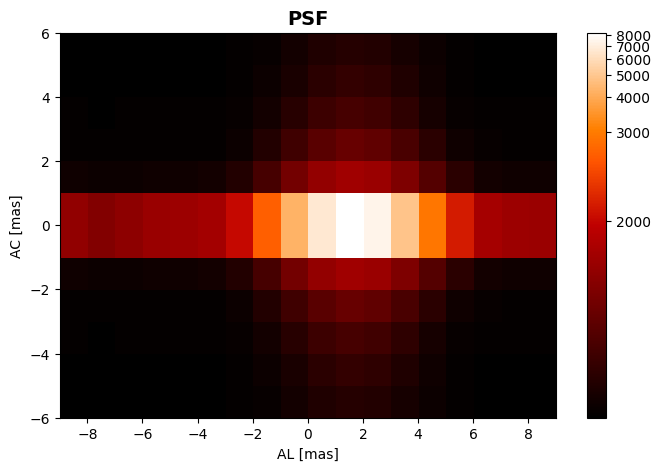

In [28]:
bs.display_psf(cube[0], '2d')

## Visualizations

/tmp/ipykernel_213218/3196809085.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='HUE', loc='best', fontsize='large')


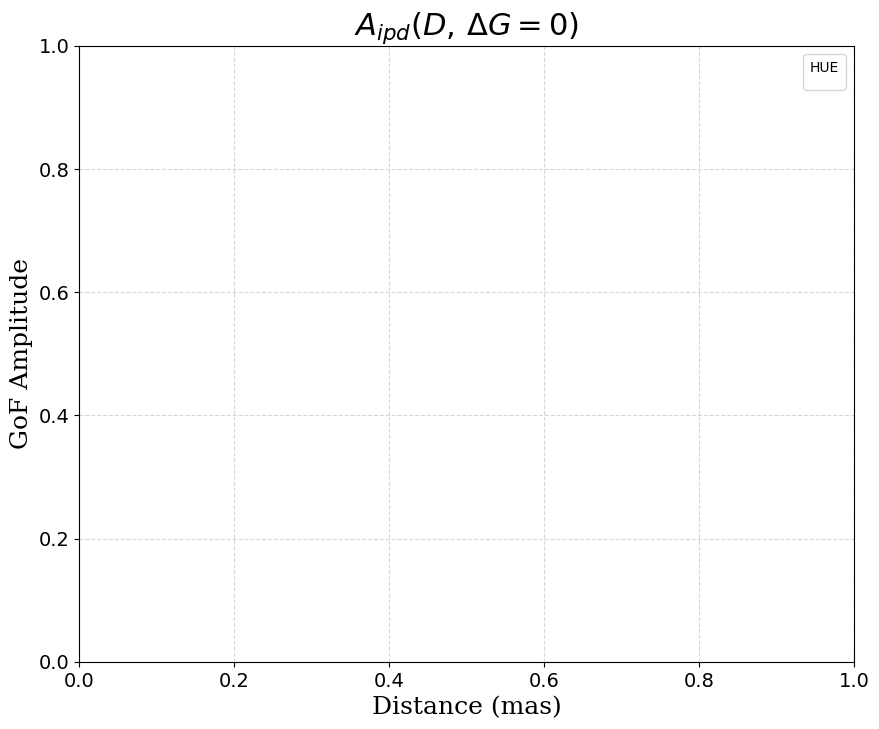

In [10]:
plot_groups(
    sd[(sd['delta_m'].isin([0,4])) & (sd['D_mas'] < 221)],
    x='D_mas',
    y='gof_amp', 
    hue='G',
    hue_label=r"$G$",
    xlabel='Distance (mas)', 
    ylabel='GoF Amplitude',
    title=r'$A_{ipd}(D,\,\Delta G=0)$'
)

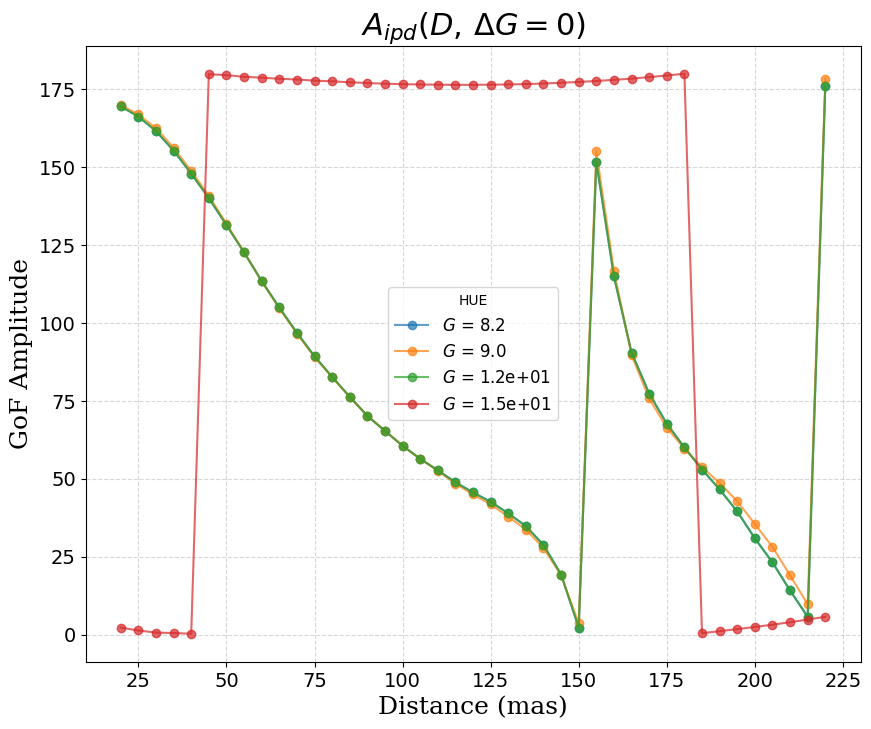

In [4]:
plot_groups(
    sd[(sd['delta_m'].isin([0,4])) & (sd['D_mas'] < 221)],
    x='D_mas',
    y='gof_phase', 
    hue='G',
    hue_label=r"$G$",
    xlabel='Distance (mas)', 
    ylabel='GoF Amplitude',
    title=r'$A_{ipd}(D,\,\Delta G=0)$'
)

In [4]:
delta_bright = {x: sd[(sd['delta_m'] == x) & (sd['G'] < 10)] for x in range(4)}
delta_faint = {x: sd[(sd['delta_m'] == x) & (sd['G'] > 15)] for x in range(4)}

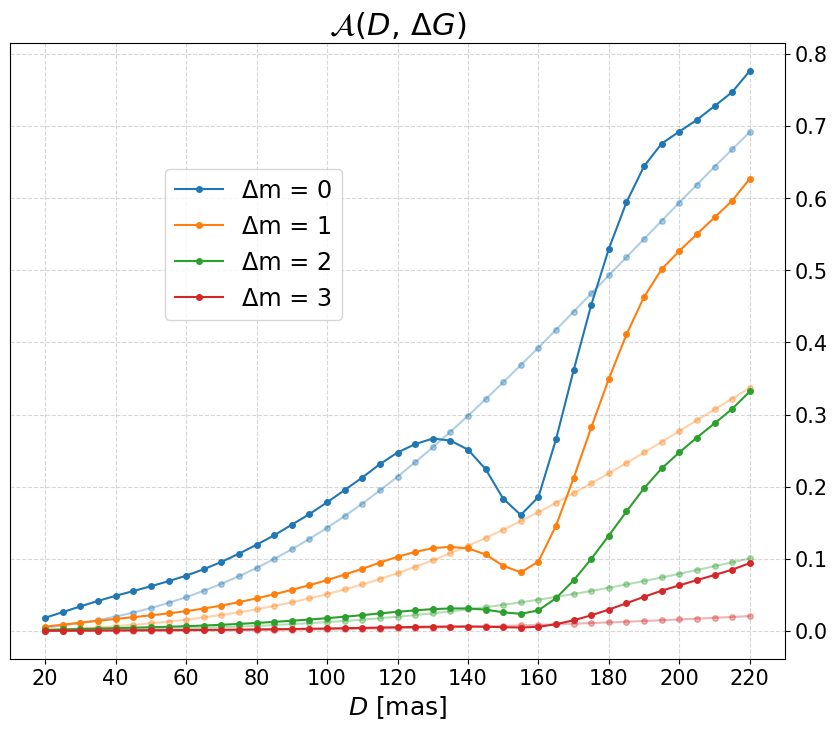

In [ ]:
plt.figure(figsize=(10,8))
for dm in range(4):
    plt.plot(delta_bright[dm]['D_mas'], delta_bright[dm]['gof_amp'], '-o', markersize=4, label=f'Δm = {dm}', alpha=1, c=f'C{dm}')
    plt.plot( delta_faint[dm]['D_mas'],  delta_faint[dm]['gof_amp'], '-o', markersize=4, alpha=0.35, c=f'C{dm}')
plt.xlabel(r'$D$ [mas]', fontdict=gp.plots.label_font)
# plt.ylabel(r'$\mathcal{A}$', fontdict=gp.plots.label_font)
plt.title(r'$\mathcal{A}(D,\,\Delta G)$', fontdict=gp.plots.title_font)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc=(0.2, 0.55), fontsize='xx-large')
plt.xticks(ticks=np.arange(20,221, 20), fontsize=15)
ax = plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.tick_params(axis='y', labelsize=15, labelright=True, labelleft=False)
plt.show()

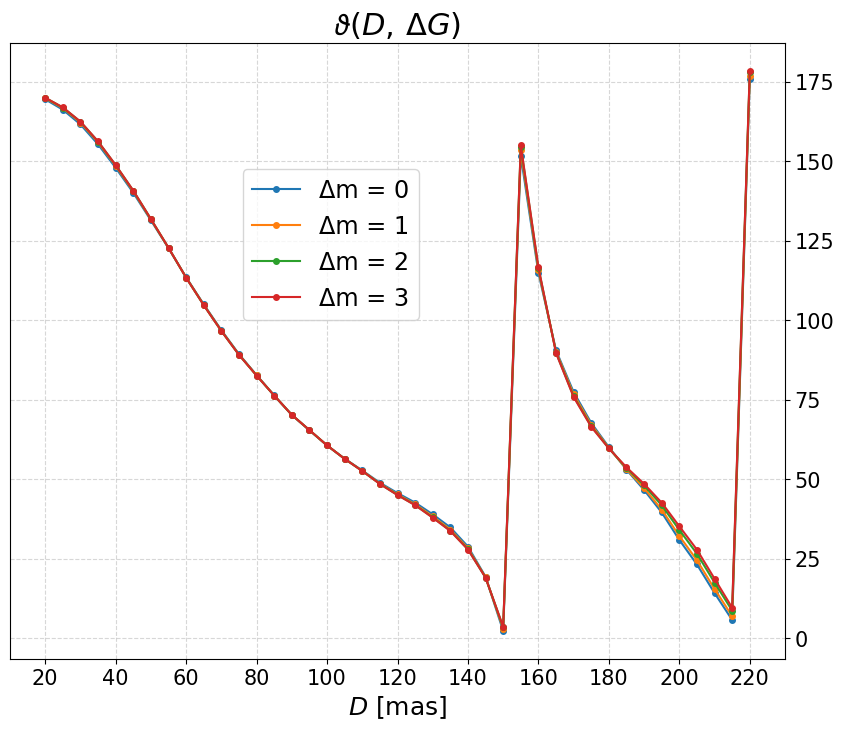

In [37]:
plt.figure(figsize=(10,8))
for dm in range(4):
    plt.plot(delta_bright[dm]['D_mas'], delta_bright[dm]['gof_phase'], '-o', markersize=4, label=f'Δm = {dm}', alpha=1, c=f'C{dm}')
    # plt.plot( delta_faint[dm]['D_mas'],  delta_faint[dm]['gof_phase'], '-o', markersize=4, alpha=0.35, c=f'C{dm}')
plt.xlabel(r'$D$ [mas]', fontdict=gp.plots.label_font)
# plt.ylabel(r'$\mathcal{A}$', fontdict=gp.plots.label_font)
plt.title(r'$\mathcal{\vartheta}(D,\,\Delta G)$', fontdict=gp.plots.title_font)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc=(0.3, 0.55), fontsize='xx-large')
plt.xticks(ticks=np.arange(20,221, 20), fontsize=15)
ax = plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.tick_params(axis='y', labelsize=15, labelright=True, labelleft=False)
plt.show()

In [4]:
cube = bs.load_psf(tn)

In [5]:
ipd = bs.IPD(cube=cube)

IPD(tn=None, gof_amp=2.08e-08, gof_phase=57.6 deg ipd_frac_multipeak=0.00%, ipd_frac_badfit=0.16%)

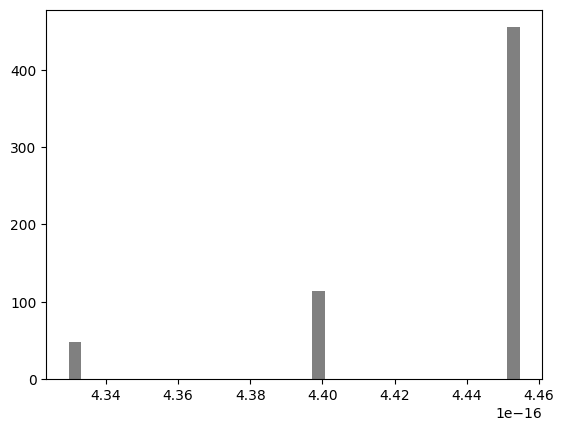

In [6]:
ipd()

findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


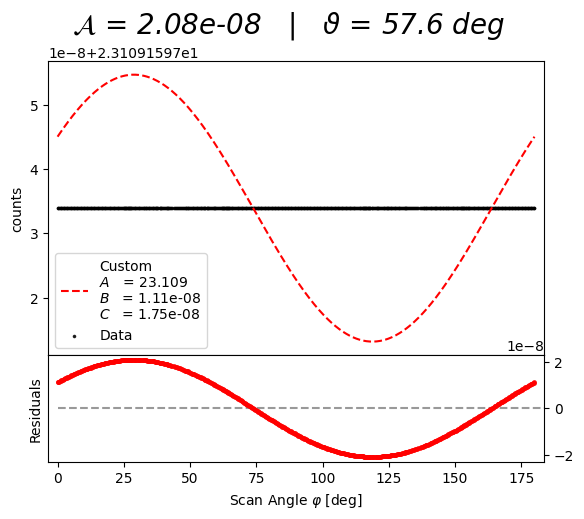

In [8]:
fig, fax = ipd.show_harmonic_fit()

In [6]:
from scipy.signal import find_peaks

MovieWriter ffmpeg unavailable; using Pillow instead.


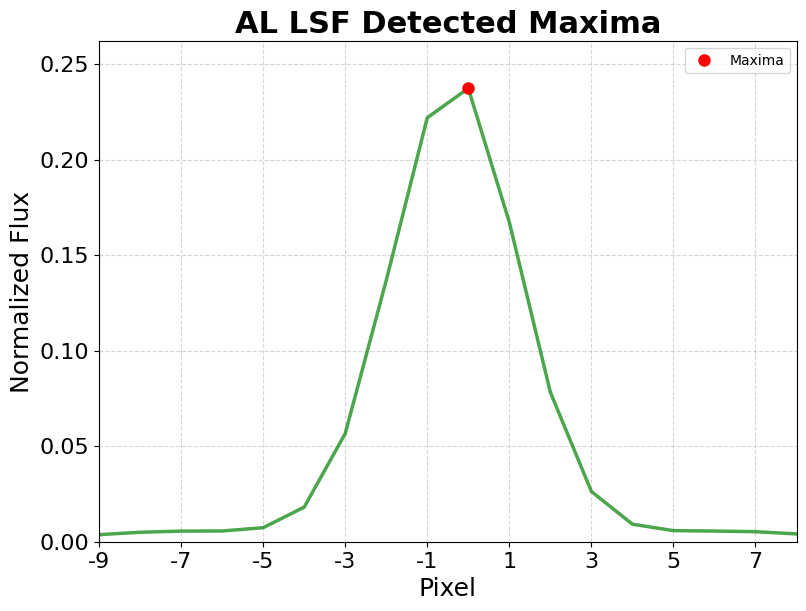

In [11]:
fig, ax = plt.subplots(figsize=(9, 6.5))

x = np.arange(len(cube[0].psf_al))
xticks = np.arange(0, len(x), 2)
xticklabels = xticks - len(x) // 2

ymax = max(np.nanmax(data.psf_al) for data in cube) * 1.1

line, = ax.plot([], [], linewidth=2.5, c='green', alpha=0.7)
peaks_plot, = ax.plot([], [], 'o', markersize=8, label='Maxima', c='red')

ax.set_xlabel('Pixel', fontdict=lf)
ax.set_ylabel('Normalized Flux', fontdict=lf)
ax.set_title('AL LSF Detected Maxima', fontdict=tf)
ax.set_xlim(0, len(x) - 1)
ax.set_ylim(0, ymax)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(linestyle='--', alpha=0.5)
ax.legend()

def update(frame):
    lsf = cube[frame].psf_al.copy()
    peaks, _ = find_peaks(lsf, height=0.01, distance=2)

    line.set_data(x, lsf)
    peaks_plot.set_data(peaks, lsf[peaks])

    # ax.set_title(f'AL LSF Detected Maxima | Frame {frame+1}/{len(cube)}', fontdict=tf)
    return line, peaks_plot

animation = FuncAnimation(fig, update, frames=len(cube), interval=200, blit=True)
animation.save('lsf_maxima_animation.gif', writer='ffmpeg', fps=15)


MovieWriter ffmpeg unavailable; using Pillow instead.


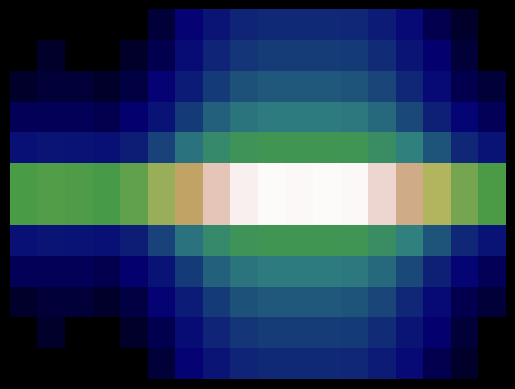

In [ ]:
norm = ImageNormalize(
    vmin=np.nanmin(cube[0].psf_2d),
    vmax=np.nanmax(cube[0].psf_2d),
    stretch=LogStretch(500),
    interval=MinMaxInterval(),
)

fig, ax = plt.subplots()
fig.axes[0].set_axis_off()
fig.set_facecolor('black')
im = ax.imshow(cube[0].psf_2d, cmap='gist_earth', origin='lower', aspect='auto', norm=norm)
# fig.colorbar(im, ax=ax)


def update(frame):
    norm = ImageNormalize(
        vmin=np.nanmin(cube[frame].psf_2d),
        vmax=np.nanmax(cube[frame].psf_2d),
        stretch=LogStretch(500),
        interval=MinMaxInterval(),
    )
    im.set_norm(norm)
    im.set_data(cube[frame].psf_2d)
    # ax.set_title(f'After CCD Readout   |   φ = {ordered_cube[frame].phi:.2f}°')
    return (im,)

animation = FuncAnimation(fig, update, frames=len(cube), interval=200)
animation.save('psf2d_animation.gif', fps=15)

MovieWriter ffmpeg unavailable; using Pillow instead.


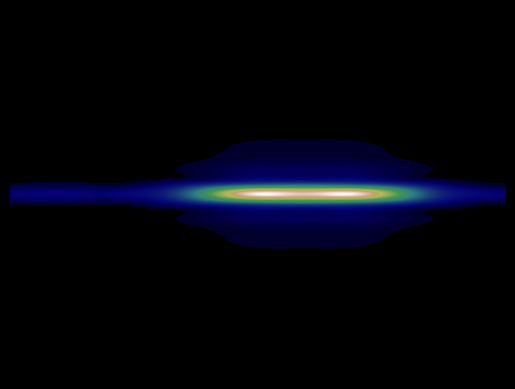

In [16]:
fig, ax = plt.subplots()
fig.axes[0].set_axis_off()
fig.set_facecolor('black')
im = ax.imshow(cube[0].psf_hr, cmap='gist_earth', origin='lower', aspect='auto')
# fig.colorbar(im, ax=ax)

def update(frame):
    norm = ImageNormalize(
        vmin=np.nanmin(cube[frame].psf_hr),
        vmax=np.nanmax(cube[frame].psf_hr),
        stretch=LogStretch(500),
        interval=MinMaxInterval(),
    )
    # im.set_norm(norm)
    im.set_data(cube[frame].psf_hr)
    # ax.set_title(f'After CCD Readout   |   φ = {ordered_cube[frame].phi:.2f}°')
    return (im,)

animation = FuncAnimation(fig, update, frames=len(cube), interval=200)
animation.save('psfhd_animation.gif', fps=15)